In [ ]:
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciomt2024_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciomt2024_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciomt2024_class_weights.pkl"))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Train
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=20,
    class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Done.")

# Evaluate
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")

evaluate(rf, X_val,  y_val,  "Validation")
evaluate(rf, X_test, y_test, "Test")

# Confusion matrix
y_pred_test = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Random Forest — CICIoMT-2024', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_rf_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

joblib.dump(rf, os.path.join(MODELS, "ciciomt2024_random_forest.pkl"))
print("Model saved.")

Train: (350000, 38), Val: (75000, 38), Test: (75000, 38)

Training Random Forest...
Done.

Validation:
  F1:        0.9994
  AUC-ROC:   0.9999
  Precision: 0.9997
  Recall:    0.9991
  Accuracy:  0.9989

Test:
  F1:        0.9995
  AUC-ROC:   0.9999
  Precision: 0.9998
  Recall:    0.9991
  Accuracy:  0.9989


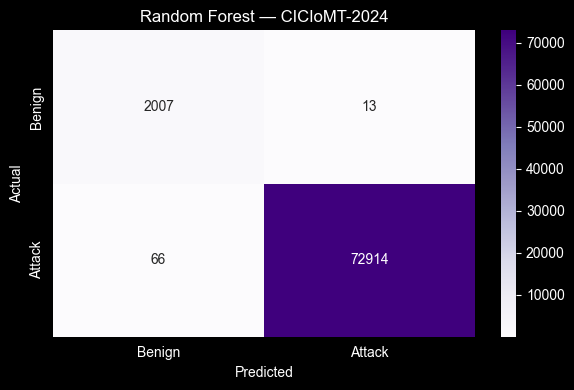


TN: 2007  FP: 13  FN: 66  TP: 72914
Model saved.


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 13 SUMMARY — Random Forest on CICIoMT-2024
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: Random Forest (ensemble)
# Config: 100 trees, max_depth=20, class_weight applied, n_jobs=-1
#
# RESULTS:
#   F1:        0.9995  ← near perfect
#   AUC-ROC:   0.9999  ← near perfect
#   Precision: 0.9998
#   Recall:    0.9991
#   Accuracy:  0.9989
#
# KEY OBSERVATION:
#   Near-perfect results across all metrics. CICIoMT-2024 medical IoT
#   attack traffic is highly structured and separable. Random Forest
#   achieves essentially perfect classification suggesting attack
#   patterns in medical IoT are very distinct from benign traffic.
#
# CROSS-DATASET COMPARISON (Random Forest):
#   CIC-IoT-2023:  F1=0.9872  AUC=0.9952
#   CICIoMT-2024:  F1=0.9995  AUC=0.9999  ← +0.0123 F1 improvement
# ══════════════════════════════════════════════════════════════════════════